## Required imports

In [2]:
import torch, numpy as np, matplotlib.pyplot as plt, pandas as pd

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,random_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Removing annoying foldes

Colab has these annoying folders called .pynb_checkpoints
These should be removed otherwise it can break the dataloader

In [1]:
import os
import shutil

ROOT_DIR = "/content/images"

for root, dirs, files in os.walk(ROOT_DIR):
    for d in dirs:
        if d == ".ipynb_checkpoints":
            checkpoint_path = os.path.join(root, d)
            shutil.rmtree(checkpoint_path)
            print(f"Removed: {checkpoint_path}")


Removed: /content/images/.ipynb_checkpoints


Transforming the data for:

- Ensuring small size of images, to use less memory
- Artificially expanding the dataset
- Introducing noise



In [10]:
transform = transforms.Compose([
    transforms.Resize((500, 500)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Loading the images into a pytorch dataset

In [11]:
dataset = datasets.ImageFolder(
    root="/content/images",
    transform=transform
)

Typically, 70-80% of data is used for training, hence train_size is 0.8 times dataset size.

In [12]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

## DataLoader

The dataloader is how PyTorch allows batch processing. We are using a batch size of 32, which means we give the model 32 items from the dataset at one time, then fine tune the model to reduce the loss, and go again.

We can't give the model the whole dataset in one go due to memory restrictions and that it can produce inconsistent results.

It is important to note that we still process the whole dataset once every epoch

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

 Test that it is working correctly

In [14]:
images, labels = next(iter(train_loader))
images.shape, labels[:5]

(torch.Size([32, 3, 500, 500]), tensor([0, 1, 1, 2, 0]))

Works!

## Model definition

In [15]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

### Load pretrained models wherever possible

Resnet18 is a pretrained CNN that we can use to make training easier.

We only want to modify the final layer of the model so we freeze the first layers.

In [16]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

NUM_CLASSES = 4
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


### Loss function

We use cross entropy loss for a classification model.

We don't need to apply softmax because the loss function does it automatically for us.

In [17]:
loss_fn = nn.CrossEntropyLoss()

Just testing that it works

In [18]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
loss = loss_fn(outputs, labels)

loss.item()

1.4689154624938965

### Optimiser

We will use SGD because it is good for almost everything. It is also the easiest and most common one that is used (along with Adam)

In [34]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
)

## Training loop

In [35]:
def train(model, train_loader, val_loader, loss_fn, optimizer, epochs):
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}"
        )


In [42]:
EPOCHS = 5
train(model, train_loader, val_loader, loss_fn, optimizer, EPOCHS)


Epoch [1/5] | Train Loss: 0.5248, Train Acc: 0.863 | Val Loss: 0.5981, Val Acc: 0.772
Epoch [2/5] | Train Loss: 0.5207, Train Acc: 0.868 | Val Loss: 0.5886, Val Acc: 0.789
Epoch [3/5] | Train Loss: 0.5063, Train Acc: 0.890 | Val Loss: 0.5912, Val Acc: 0.772
Epoch [4/5] | Train Loss: 0.5124, Train Acc: 0.877 | Val Loss: 0.5686, Val Acc: 0.789
Epoch [5/5] | Train Loss: 0.5065, Train Acc: 0.863 | Val Loss: 0.5583, Val Acc: 0.807


## Evaluating our model

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [60]:
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

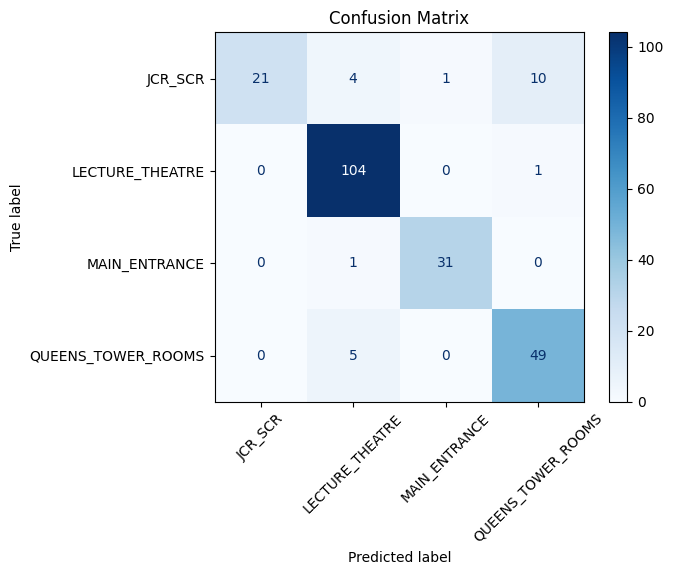

In [61]:
class_names = train_dataset.dataset.classes

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Saving the model

We save the weights into a file using python's pickle format.

In [39]:
import os
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/campus_classifier.pt")
print("Model saved to models/campus_classifier.pt")


Model saved to models/campus_classifier.pt


## Loading the model

Very easy to do with Pytorch

Create a model with the same class, initiliased with no weights or random weights.
Load in your model

In [32]:
model = resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("models/campus_classifier.pt"))
model.to(device)
print("Model loaded!")

Model loaded!


# Extra stuff


In [52]:
class_to_idx = train_dataset.dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(class_to_idx)

{'JCR_SCR': 0, 'LECTURE_THEATRE': 1, 'MAIN_ENTRANCE': 2, 'QUEENS_TOWER_ROOMS': 3}


In [53]:
jcr_idx = class_to_idx["JCR_SCR"]
qt_idx = class_to_idx["QUEENS_TOWER_ROOMS"]

misclassified_images = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, true_label, pred_label in zip(images, labels, preds):
            if true_label == jcr_idx and pred_label == qt_idx:
                misclassified_images.append(img.cpu())

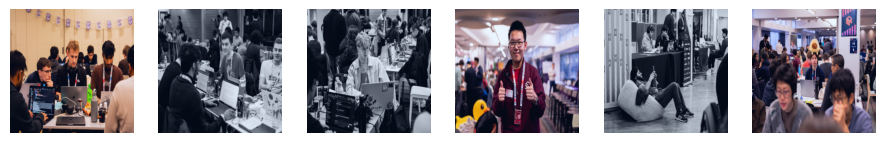

In [55]:
def show_images(images, max_images=8):
    plt.figure(figsize=(15, 5))
    for i, img in enumerate(images[:max_images]):
        plt.subplot(1, max_images, i + 1)
        img = img.permute(1, 2, 0)
        img = img * 0.225 + 0.45
        img = img.clamp(0, 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

show_images(misclassified_images)


In [59]:
qt_idx = class_to_idx["QUEENS_TOWER_ROOMS"]

qt_images = []

for img, label in train_dataset:
    if label == qt_idx:
        qt_images.append(img)
    if len(qt_images) >= 8:
        break


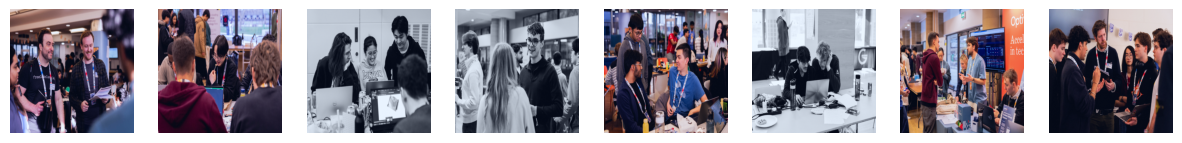

In [58]:
plt.figure(figsize=(15, 5))

for i, img in enumerate(qt_images):
    plt.subplot(1, len(qt_images), i + 1)
    img = img.permute(1, 2, 0)
    img = img * 0.225 + 0.45
    img = img.clamp(0, 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()
